#Գրադարանների բեռնում և տվյալների ներմուծում
Բեռնում ենք անհրաժեշտ գրադարանները և կարդում dataset-ը։

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#Տվյալների ուսումնասիրություն
Ստուգում ենք տվյալների չափը, տիպերը և բացակայող արժեքները

In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0

#EDA
Տեսնենք, թե քանի հաճախորդ է հեռացել(churn=1) և քանիսը մնացել(churn=0)
7963 մնացել է (80%)
2037 հեռացել (20%)



churn
0    7963
1    2037
Name: count, dtype: int64


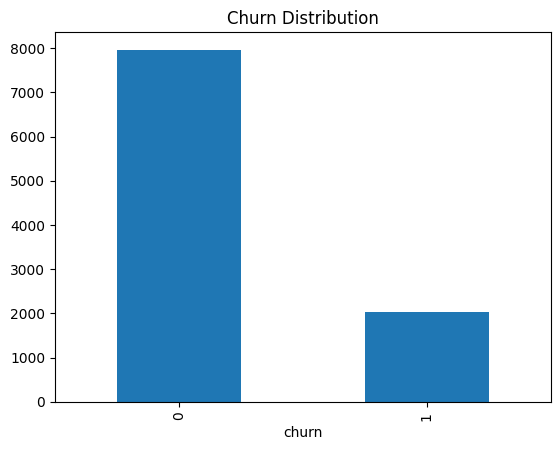

In [5]:
print(df['churn'].value_counts())
df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()

 ## Features-ների կապը churn-ի հետ
 Տեսնում ենք, որ հեռացողների տարիքը ավելի բարձր է, և բարձր մնացորդ ունեցողներն ավելի շատ են հեռանում։ Այսինքն տարիքը և բալանսը ամենակարևոր ֆակտորներն են։

In [6]:
df.groupby('churn')[['age', 'balance', 'credit_score', 'estimated_salary']].mean()


,age,balance,credit_score,estimated_salary
churn,,,,
0,37.408389,72745.296779,651.853196,99738.391772
1,44.837997,91108.539337,645.351497,101465.677531


## Տարիքի ազդեցությունը գրաֆիկորեն
Հետևություն՝

 • Churn = 0 (մնացողներ)՝ միջին տարիք ~37, box-ը 30-45 տիրույթում
 • Churn = 1 (հեռացողներ)՝ միջին տարիք ~47, box-ը 37-55 տիրույթում

Եզրակացություն՝ տարեց հաճախորդներն ավելի հաճախ են հեռանում բանկից։ Սա շատ հստակ երևում է գրաֆիկում ։

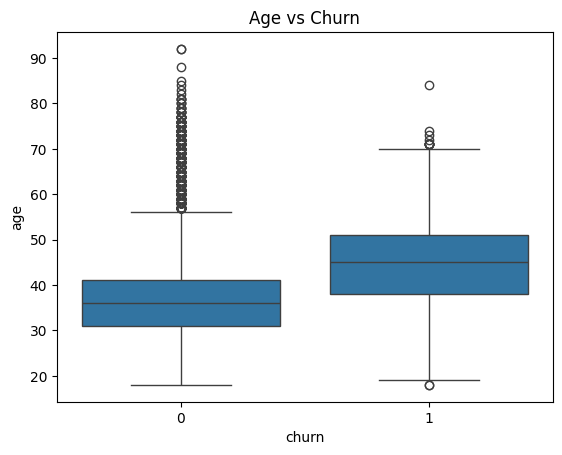

In [7]:
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age vs Churn')
plt.show()

## Տվյալների նախապաատրաստում
country և gender columns-ները տեքստային են, փոխենք, քանի որ մոդելը թվեր է սիրում։

In [8]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)
df = df.drop('customer_id', axis=1)
df.head()


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Տվյալների բաժանում՝ train և test մասերի, հետո անենք scaling
8000 row- train set (80%)
2000 row - test set (20%)
11 feature - բոլոր columns-ները

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(8000, 11) (2000, 11)


## Մոդեներ
 Logistic Regression արդյունք՝

 • Accuracy՝ 81% — թվում է լավ, բայց…
 • Class 0 (մնացողներ)՝ F1 = 0.89 — լավ կանխատեսում
 • Class 1 (հեռացողներ)՝ F1 = 0.29 — շատ վատ ⚠️

Հետևություն՝ Մոդելը «ծույլ» է , հիմնականում բոլորին 0 է կանխատեսում։ Recall = 0.20՝  նշանակում է հեռացողների 80%-ին բաց է թողնում։ Սա imbalanced data-ի խնդիր է։

## Random forest
|                |Logistic Regression|Random Forest|
|----------------|-------------------|-------------|
|Accuracy        |0.81               |**0.87**     |
|F1 (class 1)    |0.29               |**0.58**     |
|Recall (class 1)|0.20               |**0.47**     |
Random-ը շատ ավելի լավ է կանխատեսում

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



 XGBoost — երրորդ մոդելը։
|                |LR  |RF  |XGBoost |
|----------------|----|----|--------|
|Accuracy        |0.81|0.87|**0.87**|
|F1 (class 1)    |0.29|0.58|**0.63**|
|Recall (class 1)|0.20|0.47|**0.55**|
XGBoost-ը լավագույնն է ՝հեռացողներին ամենաճիշտ է կանխատեսում։

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1607
           1       0.72      0.55      0.63       393

    accuracy                           0.87      2000
   macro avg       0.81      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000



## Հիմա վերջին քայլը — feature importance-ը տեսնենք։
Feature Importance հետևություններ՝

 • Age — ամենակարևոր factor-ը  (մենք արդեն EDA-ում էլ տեսանք)
 • Estimated salary — երկրորդ կարևոր
 • Credit score — երրորդ
 • Balance — չորրորդ
 • Country, gender, credit_card — գրեթե չեն ազդում

 «Random Forest-ի feature importance-ը ցույց տվեց, որ հաճախորդի տարիքը ամենամեծ ազդեցությունն ունի churn-ի վրա, ինչը հաստատում է EDA-ում արված հետևությունները»։

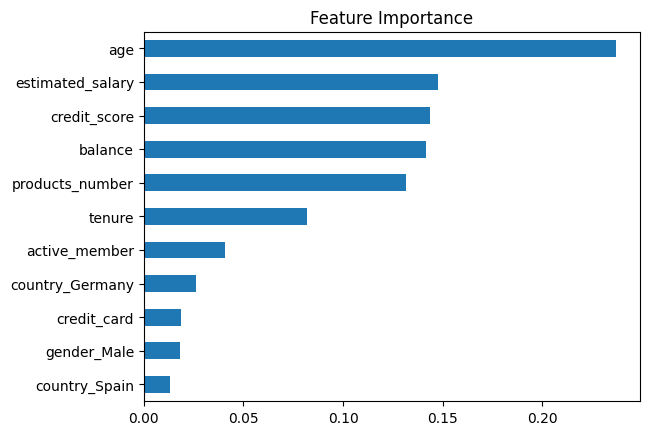

In [14]:
import pandas as pd
feat_imp = pd.Series(rf.feature_importances_,
                     index=df.drop('churn', axis=1).columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()